**Assignment no.6. Probability Distributions**

**AIM:
Generate Binomial and Poisson Distribution for given data
Plot Normal Distribution
Perform basic simulations using distributions**

**LAB Experiment Example 1:  What is the probability of 2 heads in 6 coin tosses? Fit
the Binomial distribution for the coin tosses and plot it.**

0 heads: 0.0156
1 heads: 0.0938
2 heads: 0.2344
3 heads: 0.3125
4 heads: 0.2344
5 heads: 0.0938
6 heads: 0.0156


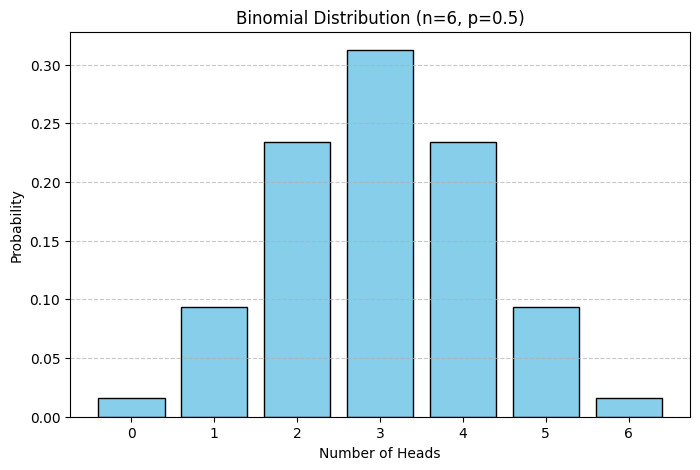

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

#1. Set parameters
n = 6    #Total coin tosses
p = 0.5    #Probability of heads (success)

#2. Define possible outcomes (0 to 6 heads)
k_values = np.arange (0, n + 1)

#3. Calculate the Probability Mass Function (PMF)
pmf_values = binom.pmf(k_values, n, p)

#4. Create the plot
plt.figure(figsize=(8,5))
plt.bar(k_values, pmf_values, color= 'skyblue', edgecolor='black')

#Formatting the chart
plt.title(f'Binomial Distribution (n={n}, p={p})')
plt.xlabel('Number of Heads')
plt.ylabel('Probability')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

#Display calculated probabilities

for k, prob in zip(k_values, pmf_values):
    print(f"{k} heads: {prob:.4f}")

plt.show()

**LAB Experiment Example 2:  A large urban hospital has, on average, 80 emergency
department admits every Monday. What is the probability that there will be more than
100? give the python code for data and plot the distribution**

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2928/528354790.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Poisson Distribution ($\lambda={mu}$)")


Probability of more than 100 admits: 0.0132


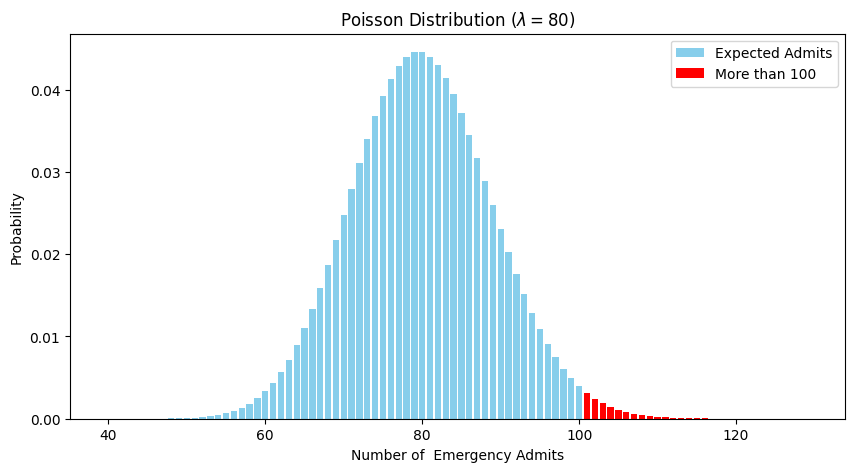

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
#parameters
mu = 80
threshold = 100
#1.calculate probability
#P(X > 100) = 1-P(X <=100)
prob = 1 - poisson.cdf(threshold,mu)
print(f"Probability of more than 100 admits: {prob:.4f}")

#2.Data for plotting
x = np.arange(40,130)
y = poisson.pmf(x,mu)

#3.Create the plot
plt.figure(figsize=(10,5))
plt.bar(x,y,color='skyblue', label='Expected Admits')
plt.bar(x[x > threshold], y[x > threshold], color = "red",label="More than 100")

plt.title(f"Poisson Distribution ($\lambda={mu}$)")
plt.xlabel("Number of  Emergency Admits")
plt.ylabel("Probability")
plt.legend()
plt.show()

**LAB Experiment Example 3:  
Suppose there are 100 students in the class and in one of the mathematics tests the
average marks scored by the students in the subject is 78 and the standard deviation is 25.
The marks of the student follow Normal probability distribution. Find the probability of
students who got marks less than 60, also write the python code for the same.**

Probability of scoring less than 60: 0.2358
Expected number of students : 23.58


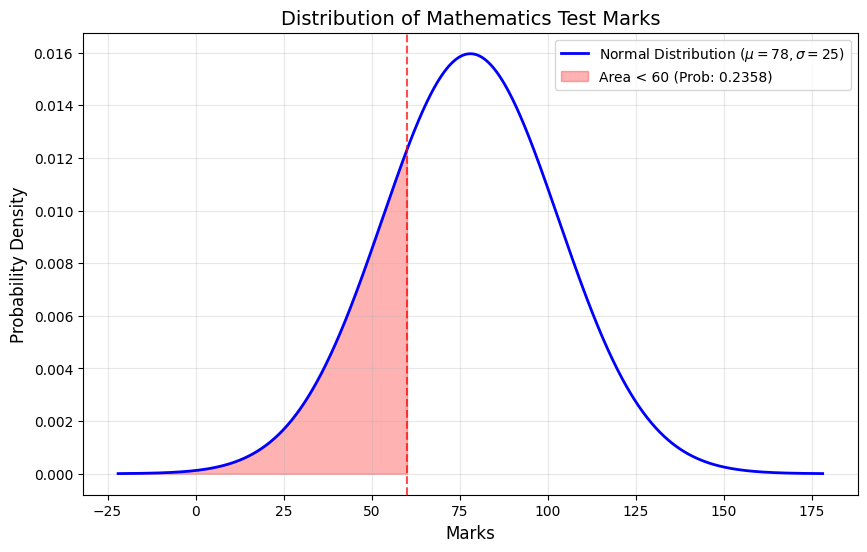

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1.define the parameters given in the problem
mu = 78          #mean
sigma = 25       #standard dev
threshold = 60   #marks limit
num_students = 100

# 2. calculate the probability
# The CDF (cumulative Distribution function) gives the probability for X < threshold
probability = stats.norm.cdf(threshold, mu, sigma)
expected_students = probability * num_students  # expected count

print(f"Probability of scoring less than 60: {probability:.4f}")
print(f"Expected number of students : {expected_students:.2f}")


#3. Create the visualization

#Generate a range of marks for the x-axis
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

y = stats.norm.pdf(x, mu, sigma) # Normal distribution curve

plt.figure(figsize=(10, 6))

plt.plot(x, y, 'b', lw=2, label=f'Normal Distribution ($\\mu={mu}, \\sigma={sigma}$)')

#Highlight the area for marks < 60
x_fill = np.linspace(mu - 4*sigma, threshold, 500)
y_fill = stats.norm.pdf(x_fill, mu, sigma)

plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label=f'Area < 60 (Prob: {probability:.4f})')

#Add vertical line at the threshold
plt.axvline(threshold, color='red', linestyle='--', alpha=0.7)

# Add titles and labels
plt.title('Distribution of Mathematics Test Marks', fontsize=14)
plt.xlabel('Marks', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

#Display the plot
plt.show()
